# Data-Driven Growth Analysis: Olist E-Commerce
### *Data Intelligence Pipeline & Demand Forecasting*

## Primera fase: Diagnóstico y Análisis Histórico

En esta primera parte se hace el análisis de los datos del marketplace brasileño *Olist*, disponibles en formato CSV en https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce, sin embargo, no se hace uso de ellos mediante los archivos csv directamente, sino que se simula un entorno de trabajo en el que dichos datos puedan ser actualizables mediante la creación de una base de datos en MySQL. Se realizan las consultas adecuadas para obtener la cantidad de pedidos e ingresos diarios.

Con estos datos se crea una visualización histórica de su evolución para identificar la tendencia de las ventas mediante medias móviles en la serie de tiempo, y su correlación con la cantidad de pedidos mediante el coeficiente de correlación de Spearman. También se obtiene el ticket promedio mensual y los patrones repetitivos semanales y mensuales (estacionalidad).

### 1. Creación de la base de datos en MySQL

En este punto, se crea la base de datos en MySQL y, posteriormente se realiza la conexión entre Python y dicha base.

In [1]:
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Cargar configuración del usuario que accederá a la base de datos
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
database = "olist_project"

# Establecer conexión entre MySQL y Python
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

In [2]:
# El siguiente código se ha comentado ya que la base de datos ya ha sido creada (si aún no está creada, debe ejecutarse)
#import pandas as pd

#data_path = "Ruta_de_los_CSV_de_Olist"

#for file in os.listdir(data_path):
#    if file.endswith(".csv"):
#        table_name = file.replace(".csv", "").replace("_dataset", "")
        
#        try:
#            temp_df = pd.read_csv(os.path.join(data_path, file))
#            temp_df.columns = [c.lower().replace(' ', '_').replace('.', '_') for c in temp_df.columns]
            
#            print(f"Cargando {table_name}...")
#            temp_df.to_sql(table_name, con=engine, if_exists='replace', index=False, chunksize=1000)
#            print(f"Tabla '{table_name}' cargada con éxito.")
            
#       except Exception as e:
#            print(f"Error al cargar {table_name}: {e}")
#            engine.dispose()
#            engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

### 2. Obtención de datos y respuesta a las primeras preguntas:

En este punto, la base de datos ya ha sido creada y conectada a Python. Se obtendrán los datos de las ventas y cantidad de pedidos diarias para responder a las preguntas:

*   **Visibilidad histórica:** ¿Cómo se ve la evolución de las ventas diarias desde el inicio de las operaciones de la empresa?
*   **Calidad en las entregas:** ¿Cuántos de los pedidos realmente llegaron al cliente? (Esto es importante ya que la fase de pronóstico no debe estar basada en datos que contengan cancelaciones, sino en entregas completadas).
*   **Identificación de patrones estacionales:** ¿Existen ciclos recurrentes (picos de demanda semanales o mensuales) que se deberían informar al equipo de logística?

**Nota: Se ha optado por considerar únicamente el precio de venta neto de cada producto, omitiendo el costo del envío, esto es debido a que no se sabe con certeza si los envíos son gestionados directamente por Olist o por paqueterías externas, por lo que no puede asegurarse que el monto de los envíos sean ingresos para la empresa. Si se tomasen en cuenta, podrían sobreestimarse los ingresos, lo que conllevaría a una toma de decisiones con alta incertidumbre. Además, se ha realizado la consulta a la base de datos de manera que la relación entre tablas sea adecuada, a manera de que no se dupliquen transacciones que podrían sesgar los ingresos y cantidad de pedidos.**

### Visibilidad Histórica (Serie de Tiempo)

In [3]:
import pandas as pd

query = '''
    SELECT 
    	DATE(O.order_purchase_timestamp) AS fecha,
        SUM(OI.price) AS ingresos_diarios,
        COUNT(DISTINCT O.order_id) AS cantidad_pedidos
    FROM olist_orders AS O
    JOIN olist_order_items AS OI ON O.order_id = OI.order_id
    WHERE O.order_status = 'delivered'
    GROUP BY fecha
    ORDER BY fecha;
'''

df_ventas = pd.read_sql(query, con=engine)

# Asegurar el tipo "datetime" de la columna de fecha (actualmente es Str)
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

print(f"El tipo de los elementos de la columna de fecha es: {type(df_ventas['fecha'][1])}")
df_ventas.head()


El tipo de los elementos de la columna de fecha es: <class 'pandas.Timestamp'>


,fecha,ingresos_diarios,cantidad_pedidos
0,2016-09-15,134.97,1
1,2016-10-03,441.98,7
2,2016-10-04,8595.89,54
3,2016-10-05,6169.77,35
4,2016-10-06,5889.96,41


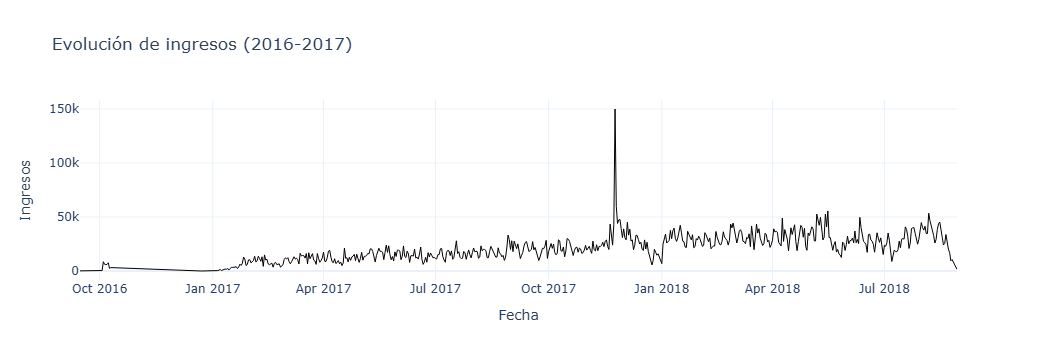

In [4]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['ingresos_diarios'],
                         name='Ingresos Diarios', line=dict(color='black', width=1)))

fig.update_layout(title='Evolución de ingresos (2016-2017)',
                  xaxis_title='Fecha', yaxis_title='Ingresos',
                  template='plotly_white', hovermode='x unified')
fig.show()

Puede notarse que en realidad aquí hay mucho "ruido" en los precios por lo que no es fácil identificar una tendencia. Para solucionar esto puede utilizarse un promedio móvil, particularmente se usará uno semanal (7 días) y uno mensual (30 días).

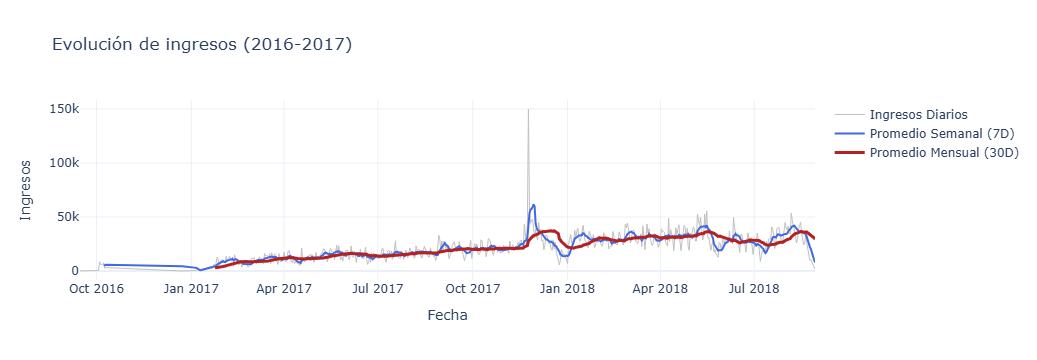

In [5]:
import plotly.graph_objects as go

df_ventas['media_7d'] = df_ventas['ingresos_diarios'].rolling(window=7).mean()
df_ventas['media_30d'] = df_ventas['ingresos_diarios'].rolling(window=30).mean()

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['ingresos_diarios'],
                         name='Ingresos Diarios', line=dict(color='silver', width=1))) #, opacity=0.5))

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['media_7d'],
                         name='Promedio Semanal (7D)', line=dict(color='royalblue', width=2)))

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['media_30d'],
                         name='Promedio Mensual (30D)', line=dict(color='firebrick', width=3)))

fig.update_layout(title='Evolución de ingresos (2016-2017)',
                  xaxis_title='Fecha', yaxis_title='Ingresos',
                  template='plotly_white', hovermode='x unified')
fig.show()

In [6]:
# La estadística de estos datos históricos
resumen = df_ventas.drop(columns=['fecha', 'media_7d', 'media_30d']).describe()
print(resumen)

# Información sobre el 20 de Noviembre el 2017 (el "pico" que llega hasta $150k de ingresos)
bf = df_ventas[df_ventas['fecha'] == '2017-11-24']
ingreso_bf = bf['ingresos_diarios'].iloc[0]

print(f'\nLos ingresos totales son de: ${df_ventas['ingresos_diarios'].sum():.2f}. ')
print(f'La cantidad de pedidos del 24-Nov-2017 es de {df_ventas['cantidad_pedidos'].max()}, que representaron ingresos de: ${ingreso_bf:.2f}. Es decir, {ingreso_bf / df_ventas['ingresos_diarios'].mean():.2f} veces más ingresos que el promedio de cualquier otro día.')

       ingresos_diarios  cantidad_pedidos
count        612.000000        612.000000
mean       21603.755082        157.643791
std        12316.810305         89.507146
min           10.900000          1.000000
25%        12822.230000         97.750000
50%        20098.560000        145.500000
75%        28726.275000        213.250000
max       149916.580000       1147.000000

Los ingresos totales son de: $13221498.11. 
La cantidad de pedidos del 24-Nov-2017 es de 1147, que representaron ingresos de: $149916.58. Es decir, 6.94 veces más ingresos que el promedio de cualquier otro día.


### Resultados:
*    **Tendencia alcista:** A pesar de que existe fluctuación en los ingresos diarios, la tendencia a lo largo de estos dos años ha sido, en general, alcista. Los ingresos han aumentado con el paso de los meses.
*    **Laguna de ventas:** Habría que analizar a detalle qué sucedió entre Octubre y Diciembre del 2016 ya que es un periodo de ingresos sumamente bajos, casi nulos.
*    **Ingresos decrecientes en el último mes:** Debe revisarse qué sucedió en la segunda mitad del mes de Octubre del 2018 ya que parece que los ingresos han bajado.
*    **El mejor día:** La mayor cantidad de ingresos de todos los días fue durante el *Black Friday* del 2017 (24 de Noviembre). Casi 7 veces más ingresos que cualquier otro día. Esto se debió al fuerte impacto que tuvo este evento, pues la cantidad de pedidos fue de 1345.
*    El total de ingresos es de más de $13.22 millones.

### Nuevas preguntas:

El hecho de que la tendencia en los ingresos diarios sea creciente, conlleva a otra pregunta: ¿Se están vendiendo más productos cada día o se están vendiendo productos más caros?

Para responder a esta pregunta es adecuado hacer una comparación entre los ingresos diarios y el volúmen de pedidos, así como obtener la evolución del ticket promedio.

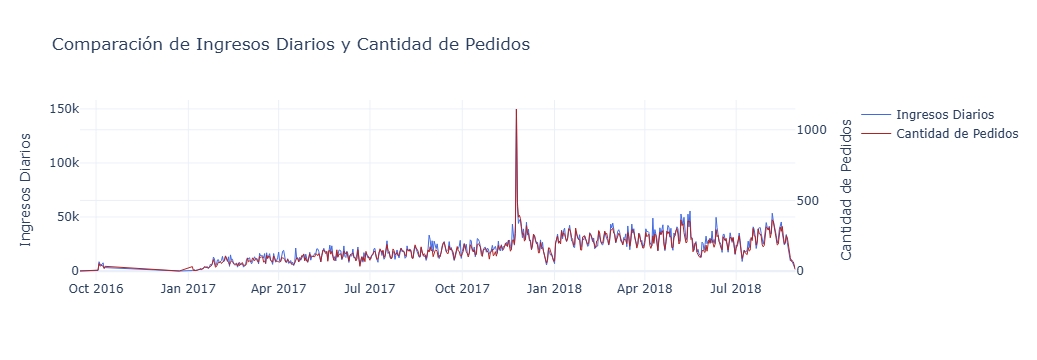

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['ingresos_diarios'],
                        mode='lines', 
                        name='Ingresos Diarios',
                        line=dict(color='royalblue', width=1)),
                        secondary_y=False)

fig.add_trace(go.Scatter(x=df_ventas['fecha'], y=df_ventas['cantidad_pedidos'],
                        mode='lines',
                        name='Cantidad de Pedidos',
                        line=dict(color='firebrick', width=1)),
                        secondary_y=True)

fig.update_layout(title_text='Comparación de Ingresos Diarios y Cantidad de Pedidos',
                 template='plotly_white',
                 hovermode='x unified')
fig.update_yaxes(title_text='Ingresos Diarios', secondary_y=False)
fig.update_yaxes(title_text='Cantidad de Pedidos', secondary_y=True)

fig.show()


Se observa que ambas variables tienen una correlación muy alta, lo cual puede cuantificarse.

Primero que nada, se debe descubrir si los datos tienen una distribución normal o no y con base en eso calcular su coeficiente de correlación. En particular, para este caso, se usará un gráfico Cuantil-Cuantil (Q-Q Plot) respaldado por el valor de $R^2$.
Además, será complementado con el test de Shapiro-Wilk, cuya hhipótesis nula ($H_0$) sugiere que la distribución es normal.

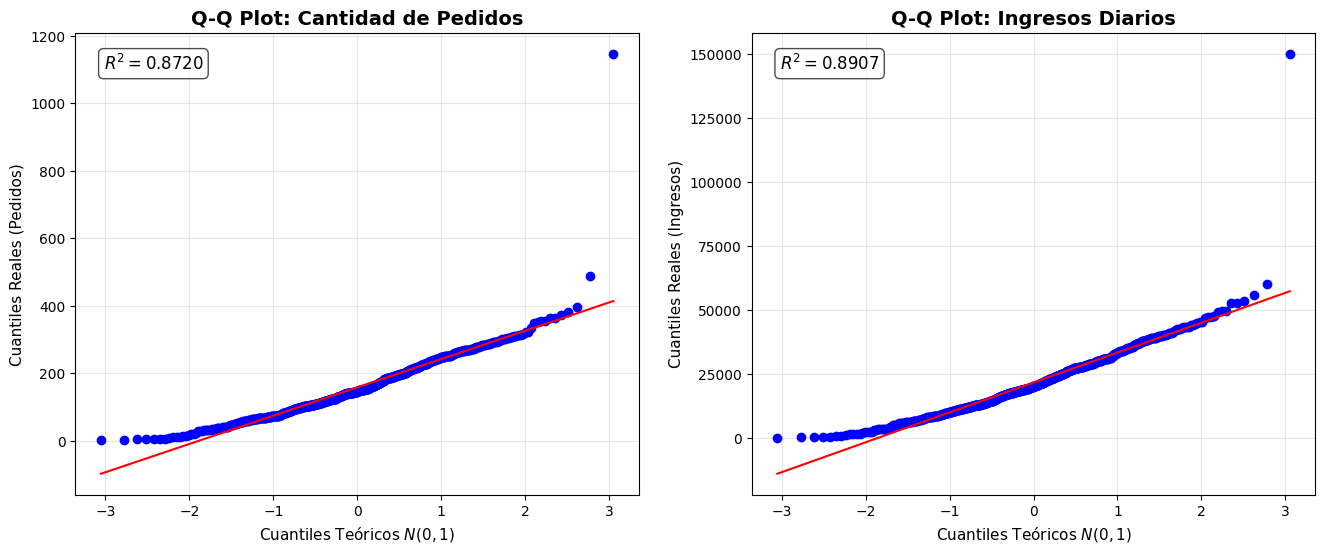

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

(osm1, osr1), (slope1, intercept1, r1) = stats.probplot(df_ventas['cantidad_pedidos'], dist="norm", plot=axes[0])
r2_pedidos = r1**2

axes[0].set_title('Q-Q Plot: Cantidad de Pedidos', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cuantiles Teóricos $N(0,1)$', fontsize=11)
axes[0].set_ylabel('Cuantiles Reales (Pedidos)', fontsize=11)
axes[0].grid(True, linestyle='-', alpha=0.3)

axes[0].text(0.05, 0.92, f'$R^2 = {r2_pedidos:.4f}$', transform=axes[0].transAxes, 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(df_ventas['ingresos_diarios'], dist="norm", plot=axes[1])
r2_ingresos = r2**2

axes[1].set_title('Q-Q Plot: Ingresos Diarios', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos $N(0,1)$', fontsize=11)
axes[1].set_ylabel('Cuantiles Reales (Ingresos)', fontsize=11)
axes[1].grid(True, linestyle='-', alpha=0.3)

axes[1].text(0.05, 0.92, f'$R^2 = {r2_ingresos:.4f}$', transform=axes[1].transAxes, 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.show()

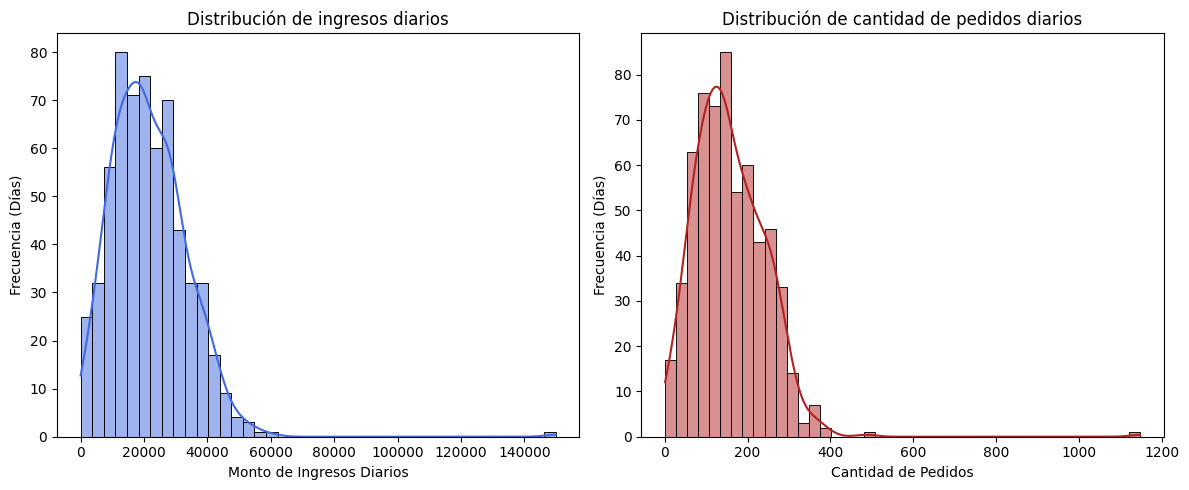

El test de Shapiro-Wilk para los Ingresos Diarios es tiene un p-value de: 5.43e-20
El test de Shapiro-Wilk para la Cantidad de Pedidos tiene un p-value de: 1.44e-21


In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df_ventas['ingresos_diarios'], ax=axes[0], kde=True, color='royalblue')
axes[0].set_title('Distribución de ingresos diarios')
axes[0].set_xlabel('Monto de Ingresos Diarios')
axes[0].set_ylabel('Frecuencia (Días)')

sns.histplot(df_ventas['cantidad_pedidos'], ax=axes[1], kde=True, color='firebrick')
axes[1].set_title('Distribución de cantidad de pedidos diarios')
axes[1].set_xlabel('Cantidad de Pedidos')
axes[1].set_ylabel('Frecuencia (Días)')

plt.savefig('Distribuciones.png')
plt.tight_layout()
plt.show()

stat_ingresos, p_ingresos = stats.shapiro(df_ventas['ingresos_diarios'])
stat_pedidos, p_pedidos = stats.shapiro(df_ventas['cantidad_pedidos'])

print(f'El test de Shapiro-Wilk para los Ingresos Diarios es tiene un p-value de: {p_ingresos:.2e}')
print(f'El test de Shapiro-Wilk para la Cantidad de Pedidos tiene un p-value de: {p_pedidos:.2e}')

Los Q-Q Plots y las $R^2$ de cada variable que se ha revisado (cantidad de pedidos e ingresos diarios) revelan que los datos no siguen una distribución estándar (presentan una función de distribución de probabilidad con colas pesadas), adicionalmente, los valores $p$ obtenidos, tanto para los ingresos diarios, como para la cantidad de pedidos son mucho menores que 0.05 ($p \ll 0.05$) por lo que se rechaza la hipótesis nula (las distribuciones son normales). Estas evidencias indican que no debe usarse el coeficiente de correlación de Pearson, sino el de Spearman.

In [10]:
coef, p = stats.spearmanr(df_ventas['ingresos_diarios'], df_ventas['cantidad_pedidos'])
print(f'El coeficiente de correlación de Spearman es: {coef}')

El coeficiente de correlación de Spearman es: 0.9610471352633666


### Resultado:
*    Un valor alto del coeficiente de correlación de Spearman implica una alta correlación entre los ingresos y los pedidos día a día, por lo que el aumento en los pedidos diarios va acompañado de un incremento en los ingresos.

### Ticket Mensual Promedio

Aquí se obtiene la visualización de la evolución del ticket mensual promedio.

In [11]:
import plotly.express as px

df_mensual = df_ventas.resample('ME', on='fecha').sum()
df_mensual['ticket_promedio'] = df_mensual['ingresos_diarios'] / df_mensual['cantidad_pedidos']

fig = px.line(df_mensual, y='ticket_promedio',
             title='Evolución del Ticket Mensual promedio',
             labels={'fecha': 'Fecha', 'ticket_promedio': 'Ticket Mensual Promedio'})

fig.update_layout(template='plotly_white',
                 hovermode='x unified')

fig.show()

In [12]:
ticket_promedio_total = df_ventas['ingresos_diarios'].sum() / df_ventas['cantidad_pedidos'].sum()
print(f'El ticket promedio total es: ${ticket_promedio_total:.2f}')

El ticket promedio total es: $137.04


La evolución del ticket mensual promedio es relativamente constante a partir de Enero del 2017, rondando aproximadamente $119.98

El hecho de que el ticket mensual promedio sea casi constante refuerza el hecho de que el incremento en los ingresos diarios se debe al volúmen de pedidos realizados y no necesariamente al alza de los precios o venta de productos más caros. En palabras simples: Si cada ticket es similar, entonces la única forma de que los ingresos aumenten es porque *hay más tickets*.

### ¿Que sucede con las *lagunas* de datos del 2016?
Por otra parte, se tiene una temporada sin datos en el mes de Noviembre del 2016. Veamos con mayor detalle que sucedió en este periodo.

In [13]:
df_ventas.head(15)

,fecha,ingresos_diarios,cantidad_pedidos,media_7d,media_30d
0,2016-09-15,134.97,1,NaN,NaN
1,2016-10-03,441.98,7,NaN,NaN
2,2016-10-04,8595.89,54,NaN,NaN
3,2016-10-05,6169.77,35,NaN,NaN
4,2016-10-06,5889.96,41,NaN,NaN
5,2016-10-07,6075.35,38,NaN,NaN
6,2016-10-08,7592.89,36,4985.830000,NaN
7,2016-10-09,2399.70,20,5309.362857,NaN
8,2016-10-10,3159.57,34,5697.590000,NaN
9,2016-12-23,10.90,1,4471.162857,NaN


Por la parte de la bajada de ventas del mes de Agosto del 2018, habría que revisar que no haya datos faltantes:

In [14]:
df_ventas.tail(30)

,fecha,ingresos_diarios,cantidad_pedidos,media_7d,media_30d
582,2018-07-31,44804.02,313,34244.294286,28135.599667
583,2018-08-01,40244.22,306,34253.002857,28714.667000
584,2018-08-02,37834.35,292,34694.477143,29105.728000
585,2018-08-03,41477.14,308,36604.802857,29316.640333
586,2018-08-04,34646.27,236,38009.510000,29521.835000
587,2018-08-05,34701.48,269,38759.205714,30053.896333
588,2018-08-06,53475.41,363,41026.127143,31542.518000
589,2018-08-07,46744.20,353,41303.295714,32631.834667
590,2018-08-08,42449.38,310,41618.318571,33401.449000
591,2018-08-09,39659.48,280,41879.051429,34119.178667


Esto muestra que existen tres *lagunas* en los datos:
*    **Septiembe 2016:** El único registro es del día 15 de Septiembre.
*    **Octubre 2016:** Solamente se tienen registros desde el día 3 hasta el 10 de Octubre.
*    **Diciembre 2016:** Se tiene únicamente un registro, el del día 23 de Diciembre.

La ausencia de datos entre Septiembre y Diciembre del 2016 debe comunicarse al equipo de ventas y logística. Su ausencia deja algunos caminos que podrían tomarse:
*   Considerar los datos únicamente del periodo en el que son constantes (omitir todos los registros anteriores a Enero del 2016).
*   Considerar su ausencia durante la interpretación de los resultados.
*   No es muy recomendable sustituir esos valores por ceros (sesgarían demasiado los promedios de esos meses) ni rellenarlos con valores cercanos al promedio (existe un riesgo de sesgar, nuevamente, los resultados de esos meses).

### ¿Cuántos de los pedidos realmente llegaron al cliente?

Por la forma en la que se consultaron los datos y se construyó el dataframe (seleccionando únicamente aquellos pedidos cuyo estado es *delivered*), la respuesta es dada directamente por la cantidad de datos que se tienen.

In [15]:
query_entregas = '''
    SELECT
    	COUNT(order_id) AS 'Pedidos Totales',
        SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS 'Entregados',
    	SUM(CASE WHEN order_status = 'canceled' THEN 1 ELSE 0 END) AS 'Cancelados',
        SUM(CASE WHEN order_status = 'shipped' THEN 1 ELSE 0 END) AS 'En Proceso'
    FROM olist_orders;
'''

exito_entregas = pd.read_sql(query_entregas, con=engine)
pedidos_totales = exito_entregas['Pedidos Totales'][0]
entregados = exito_entregas['Entregados'][0]
cancelados = exito_entregas['Cancelados'][0]
en_proceso = exito_entregas['En Proceso'][0]
ratio_ok = entregados/pedidos_totales
ratio_cancelados = cancelados/pedidos_totales
ratio_en_proceso = en_proceso/pedidos_totales

print(f'De un total de {pedidos_totales} pedidos, se han entregado {int(entregados)} y se han cancelado {int(cancelados)}, lo que implica una tasa de éxito de {ratio_ok*100:.2f}%.')
print(f'La tasa de cancelaciones es de {ratio_cancelados*100:.2f}%, mientras que los pedidos que se encuentran en proceso representan el {ratio_en_proceso*100:.2f}. Por lo que el {(1 - (ratio_ok + ratio_cancelados + ratio_en_proceso))*100:.2f}% corresponde a pedidos sin información disponible.')

De un total de 99441 pedidos, se han entregado 96478 y se han cancelado 625, lo que implica una tasa de éxito de 97.02%.
La tasa de cancelaciones es de 0.63%, mientras que los pedidos que se encuentran en proceso representan el 1.11. Por lo que el 1.24% corresponde a pedidos sin información disponible.


### ¿Existen *picos* recurrentes en la semana?

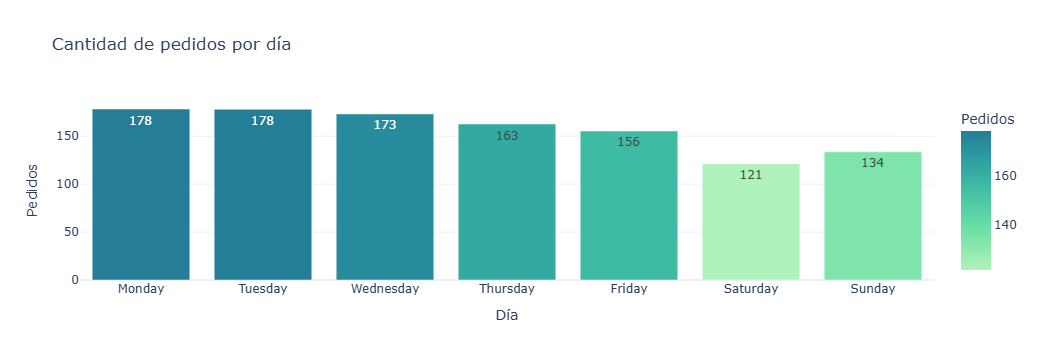

In [16]:
df_ventas['dia_semana'] = df_ventas['fecha'].dt.day_name()
week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_semanal = df_ventas.groupby('dia_semana')[['ingresos_diarios', 'cantidad_pedidos']].mean().reindex(week).reset_index()

fig = px.bar(df_semanal, x='dia_semana', y='cantidad_pedidos',
            title='Cantidad de pedidos por día',
            color='cantidad_pedidos',
            text_auto='.0f',
            color_continuous_scale='Tealgrn',
            labels={'dia_semana': 'Día', 'cantidad_pedidos': 'Pedidos'})

fig.update_layout(template='plotly_white')

fig.show()

In [17]:
pedidos_martes = df_semanal.iloc[1, 2]
pedidos_sabado = df_semanal.iloc[5, 2]

print(f'La cantidad de pedidos promedio de los sábados es {(1 - pedidos_sabado/pedidos_martes) * 100:.2f}% menor que el día que más pedidos hay (Lunes o Martes).')

La cantidad de pedidos promedio de los sábados es 31.92% menor que el día que más pedidos hay (Lunes o Martes).


Estos datos muestran que la cantidad de pedidos va disminuyendo conforme se aproxima el fin de semana, siendo los Sábados cuando menos pedidos se hacen (casi 32% menos que los Lunes o Martes, los que, aparentemente, son los días en que hay más pedidos). Sin embargo, una sospecha no es suficiente para afirmarlo, para validar la observación descriptiva, y confirmar si esta ciclicidad es una propiedad de los datos bajo estudio, se usará la función de autocorrelación (ACF), mientras que la función de autocorrelación parcial (PACF) permitirá aislar la influencia directa de los retardos (lags) previos sobre la demanda actual.

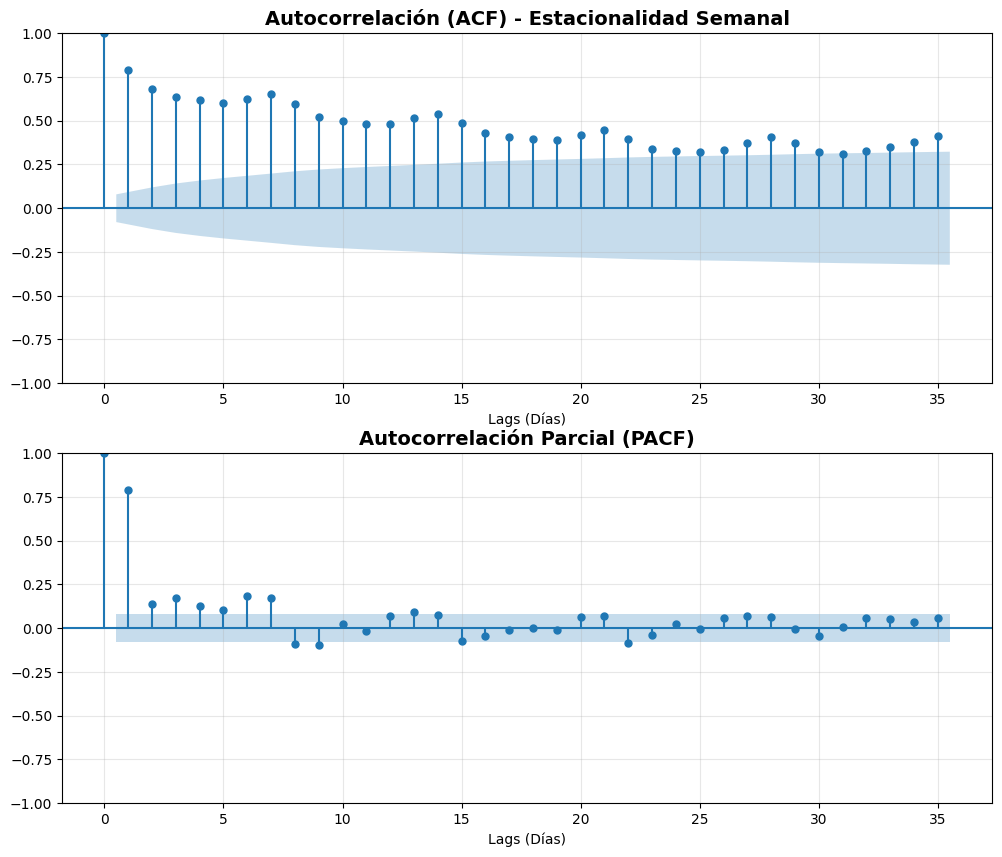

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_diario = df_ventas.groupby(df_ventas['fecha'].dt.date)['cantidad_pedidos'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10))

plot_acf(df_diario, lags=35, ax=ax1)
ax1.set_title('Autocorrelación (ACF) - Estacionalidad Semanal', fontsize=14, fontweight='bold')
ax1.set_xlabel('Lags (Días)')
ax1.grid(True, alpha=0.3)

plot_pacf(df_diario, lags=35, ax=ax2)
ax2.set_title('Autocorrelación Parcial (PACF)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Lags (Días)')
ax2.grid(True, alpha=0.3)

#plt.savefig('ACF-PACF.png')
plt.show()


Los resultados mostrados en estas gráficas confirman que el ciclo semanal no es una simple sospecha, sino que es un patrón estructural dentro de los registros de los pedidos en la empresa. En la primera (ACF) se observa que **cada 7 días hay un "pico"**, correspondiente a una semana, lo cual da soporte estadístico a la estacionalidad identificada previamente (los Lunes y Martes son los días de mayor recepción de pedidos).

Por otra parte, la PACF sugiere que la influencia directa de días previos sobre la demanda actual es significativa principalmente hasta un día anterior, mientras que el resto de los rezagos no presentan una contribución estructural dominante.

### ¿Qué sucede con el promedio de pedidos mensuales?

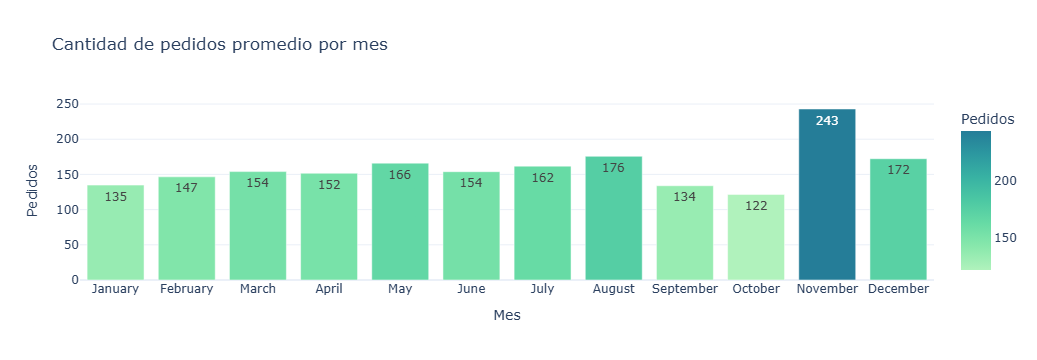

In [19]:
df_ventas['mes'] = df_ventas['fecha'].dt.month_name()
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df_mensual = df_ventas.groupby('mes')[['ingresos_diarios', 'cantidad_pedidos']].mean().reindex(months).reset_index()

fig = px.bar(df_mensual, x='mes', y='cantidad_pedidos',
            title='Cantidad de pedidos promedio por mes',
            color='cantidad_pedidos',
            text_auto='.0f',
            color_continuous_scale='Tealgrn',
            labels={'mes': 'Mes', 'cantidad_pedidos': 'Pedidos'})

fig.update_layout(template='plotly_white')

fig.show()

Este gráfico muestra el impacto que tiene la baja densidad de datos en los meses de Septiembre y Octubre, ya que, en comparación con meses como Marzo o Abril que si tienen registros en, por lo menos, dos años, estos carecen de representatividad de varios años, contando únicamente con registros del ciclo 2017, lo que vuelve la comparación "injusta".

Por otra parte, también se nota el impacto que tiene el *Black Friday* en la cantidad de pedidos del mes de Noviembre.

Finalmente, en los meses correspondientes al primer trimestre, puede notarse un incremento paulatino en los pedidos. No obstante, no puede asegurarse que esto se deba al fenómeno conocido como "cuesta de Enero", posterior a grandes gastos que suele hacer la gente durante épocas decembrinas, sino que podría deberse a que precisamente estos meses están contenidos en los primeros registros que se tienen y coincide con la fase de inserción al mercado y escalamiento inicial de Olist, por lo que inicialmente la cantidad de pedidos era menor comparada con fechas más recientes (la tendencia ha sido alcista a lo largo del tiempo). Esta respuesta únicamente podría darse teniendo una mayor cantidad de registros anuales.

## Conclusiones de la fase 1:
*    **Crecimiento Orgánico con Volatilidad Controlada:** Existe una tendencia alcista robusta en los ingresos diarios. Aunque el "ruido" es alto, las medias móviles de 7 y 30 días confirman una aceleración del negocio a partir de 2017.
*    **Validación Estadística:** La correlación de Spearman de 0.96 confirma una correlación casi lineal entre volumen de pedidos e ingresos, validando que cualquier modelo que prediga correctamente la cantidad de pedidos será un predictor fiel de los ingresos futuros.
*    **Estabilidad del Ticket Promedio ($137.04):** Se determinó que el aumento de ingresos no se debe a un incremento en precios o venta de productos de lujo, sino a un aumento en el volumen de operaciones. El ticket promedio es notablemente estable, lo que facilita el pronóstico basado en conteo de pedidos.
*    **Ausencia de Datos:** Se detectaron periodos con ausencia de datos históricos en
     *   **Septiembe 2016:** El único registro es del día 15 de Septiembre.
     *   **Octubre 2016:** Solamente se tienen registros desde el día 3 hasta el 10 de Octubre.
     *   **Diciembre 2016:** Se tiene únicamente un registro, el del día 23 de Diciembre.
*    **Tasa de Éxito de Entregas:** La tasa de éxito en las entregas es de 97.02%, mientras que las cancelaciones representan el 0.63% de los pedidos totales.
*    **Ciclo Operativo Semanal:** Se confirmó una estacionalidad estadística con un ciclo de 7 días. El pico máximo de actividad ocurre los Lunes y Martes, mientras que los Sábados presentan una reducción operativa del 32% respecto al pico. Esto sugiere una reconfiguración de la carga logística, priorizando la capacidad de procesamiento a inicios de semana para evitar cuellos de botella.
*    **Ciclo Operativo Mensual:** A pesar de la baja densidad de datos que se tiene como para poder hacer conclusiones certeras con respecto a una estacionalidad mensual, todo apunta a que días de ventas masivas (como el *Black Friday*) realmente tienen un gran impacto en la cantidad de pedidos y, por lo tanto, de los ingresos mensuales. Por otra parte, no puede asegurarse que la cantidad menor de pedidos durante el primer trimestre se deba a la *cuesta de Enero* o a su coincidencia con el inicio de registros de Olist. Para dar alguna conclusión es necesario tener una mayor cantidad de registros anuales.

